<a href="https://colab.research.google.com/github/mrsaeedalharbl-ux/Lab-0.01/blob/main/OliveOil_FTIR_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import_data_01

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving FTIR_Spectra_olive_oils.csv to FTIR_Spectra_olive_oils.csv


In [ ]:
# @title
import io

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("اسم الملف:", filename)
print("حجم البيانات:", df.shape)

df.head()

اسم الملف: FTIR_Spectra_olive_oils.csv
حجم البيانات: (572, 121)


,Sample Number:,1,1.1,2,2.1,3,3.1,4,4.1,5,...,56,56.1,57,57.1,58,58.1,59,59.1,60,60.1
0,Group Code:,1,1,1,1,1,1,1,1,1,...,4,4,4,4,4,4,4,4,4,4
1,Wavenumbers,Greece,Greece,Greece,Greece,Greece,Greece,Greece,Greece,Greece,...,Spain,Spain,Spain,Spain,Spain,Spain,Spain,Spain,Spain,Spain
2,798.892,0.127523009,0.126498181,0.130411785,0.130022227,0.128601989,0.128217254,0.126174933,0.126466053,0.127060105,...,0.128081486,0.127703821,0.127753276,0.12689499,0.126701768,0.126685314,0.130538546,0.128416816,0.13099101,0.130263968
3,800.8215,0.127949615,0.127130974,0.130675401,0.130406662,0.128789565,0.128282253,0.126732773,0.126915413,0.127551128,...,0.128827468,0.128164684,0.127986509,0.12721772,0.127097751,0.127238698,0.130680936,0.128996456,0.131317107,0.130737854
4,802.751,0.129282219,0.128510777,0.13201661,0.132018029,0.130022276,0.129636635,0.128243765,0.128254118,0.128899981,...,0.130061537,0.129522343,0.129284594,0.128557439,0.128209423,0.128392346,0.131650943,0.130232478,0.132793931,0.131845175


In [ ]:
print(df.columns)
print(df.shape)
df.head()

Index(['Sample Number:', '1', '1.1', '2', '2.1', '3', '3.1', '4', '4.1', '5',
       ...
       '56', '56.1', '57', '57.1', '58', '58.1', '59', '59.1', '60', '60.1'],
      dtype='object', length=121)
(572, 121)


,Sample Number:,1,1.1,2,2.1,3,3.1,4,4.1,5,...,56,56.1,57,57.1,58,58.1,59,59.1,60,60.1
0,Group Code:,1,1,1,1,1,1,1,1,1,...,4,4,4,4,4,4,4,4,4,4
1,Wavenumbers,Greece,Greece,Greece,Greece,Greece,Greece,Greece,Greece,Greece,...,Spain,Spain,Spain,Spain,Spain,Spain,Spain,Spain,Spain,Spain
2,798.892,0.127523009,0.126498181,0.130411785,0.130022227,0.128601989,0.128217254,0.126174933,0.126466053,0.127060105,...,0.128081486,0.127703821,0.127753276,0.12689499,0.126701768,0.126685314,0.130538546,0.128416816,0.13099101,0.130263968
3,800.8215,0.127949615,0.127130974,0.130675401,0.130406662,0.128789565,0.128282253,0.126732773,0.126915413,0.127551128,...,0.128827468,0.128164684,0.127986509,0.12721772,0.127097751,0.127238698,0.130680936,0.128996456,0.131317107,0.130737854
4,802.751,0.129282219,0.128510777,0.13201661,0.132018029,0.130022276,0.129636635,0.128243765,0.128254118,0.128899981,...,0.130061537,0.129522343,0.129284594,0.128557439,0.128209423,0.128392346,0.131650943,0.130232478,0.132793931,0.131845175


In [ ]:
# أرقام الموجات FTIR
wavenumbers = pd.to_numeric(df.iloc[1:, 0], errors='coerce')

# قيم FTIR
spectra = df.iloc[1:, 1:].apply(pd.to_numeric, errors='coerce')

print("عدد نقاط الطيف:", len(wavenumbers))
print("عدد العينات:", spectra.shape[1])

print("\nأول أرقام موجية:")
print(wavenumbers.head())

عدد نقاط الطيف: 571
عدد العينات: 120

أول أرقام موجية:
1         NaN
2    798.8920
3    800.8215
4    802.7510
5    804.6805
Name: Sample Number:, dtype: float64


clean_data_02

In [ ]:
# الاحتفاظ فقط بأرقام الموجات الصالحة
valid = wavenumbers.notna()

wavenumbers = wavenumbers[valid].to_numpy()
spectra = spectra.loc[valid].to_numpy()

print("Wavenumbers:", wavenumbers.shape)
print("Spectra:", spectra.shape)

Wavenumbers: (570,)
Spectra: (570, 120)


visualize_spectra_03

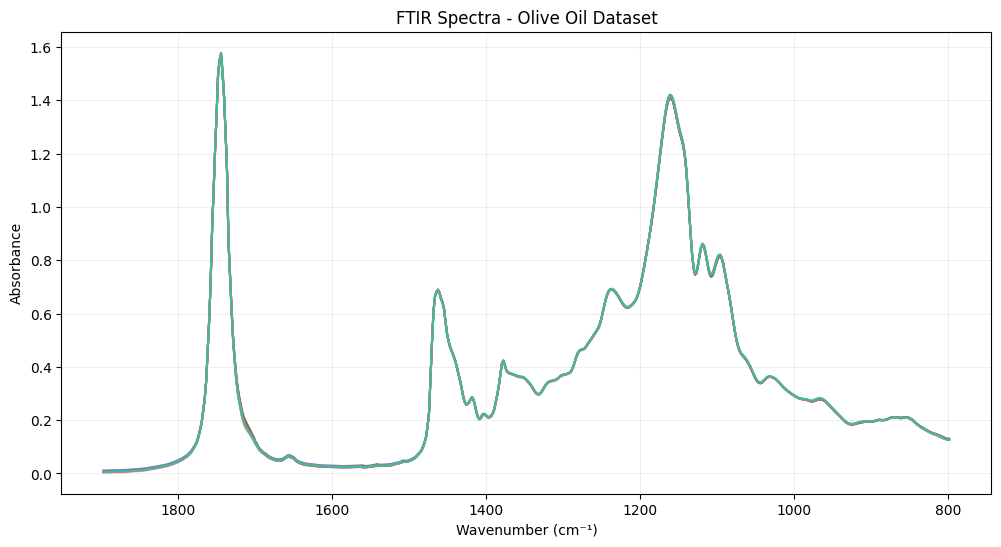

In [ ]:
# @title
plt.figure(figsize=(12, 6))

for i in range(min(10, spectra.shape[1])):
    plt.plot(wavenumbers, spectra[:, i], alpha=0.7)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.title("FTIR Spectra - Olive Oil Dataset")

plt.gca().invert_xaxis()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
# @title
group_codes = df.iloc[0, 1:].astype(str).to_numpy()
countries = df.iloc[1, 1:].astype(str).to_numpy()

sample_names = df.columns[1:].astype(str).to_numpy()

metadata = pd.DataFrame({
    "Sample": sample_names,
    "Group": group_codes,
    "Country": countries
})

metadata.head(20)

,Sample,Group,Country
0,1,1,Greece
1,1.1,1,Greece
2,2,1,Greece
3,2.1,1,Greece
4,3,1,Greece
5,3.1,1,Greece
6,4,1,Greece
7,4.1,1,Greece
8,5,1,Greece
9,5.1,1,Greece


In [ ]:
print("توزيع Group:")
print(metadata["Group"].value_counts())

print("\nتوزيع Country:")
print(metadata["Country"].value_counts())

توزيع Group:
Group
4    50
2    34
1    20
3    16
Name: count, dtype: int64

توزيع Country:
Country
Spain       50
Italy       34
Greece      20
Portugal    16
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# X = العينات × نقاط الطيف
X = spectra.T

# y = الدولة
y = metadata["Country"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (120, 570)
y shape: (120,)


In [ ]:
# توحيد البيانات
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA إلى مكونين
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:")
print(pca.explained_variance_ratio_)

print("Total:")
print(pca.explained_variance_ratio_.sum())

Explained variance:
[0.47322496 0.184762  ]
Total:
0.6579869580520582


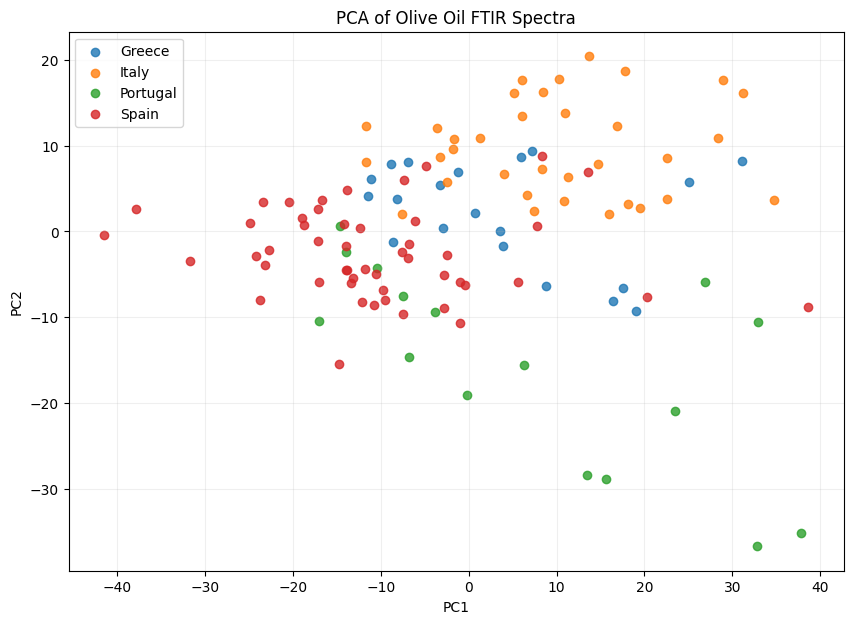

In [ ]:
plt.figure(figsize=(10, 7))

for country in metadata["Country"].unique():
    mask = y == country
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=country,
        alpha=0.8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Olive Oil FTIR Spectra")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

# تطبيق Savitzky-Golay smoothing
X_smooth = savgol_filter(
    X,
    window_length=11,
    polyorder=2,
    axis=1
)

print("الشكل الأصلي:", X.shape)
print("بعد المعالجة:", X_smooth.shape)

الشكل الأصلي: (120, 570)
بعد المعالجة: (120, 570)


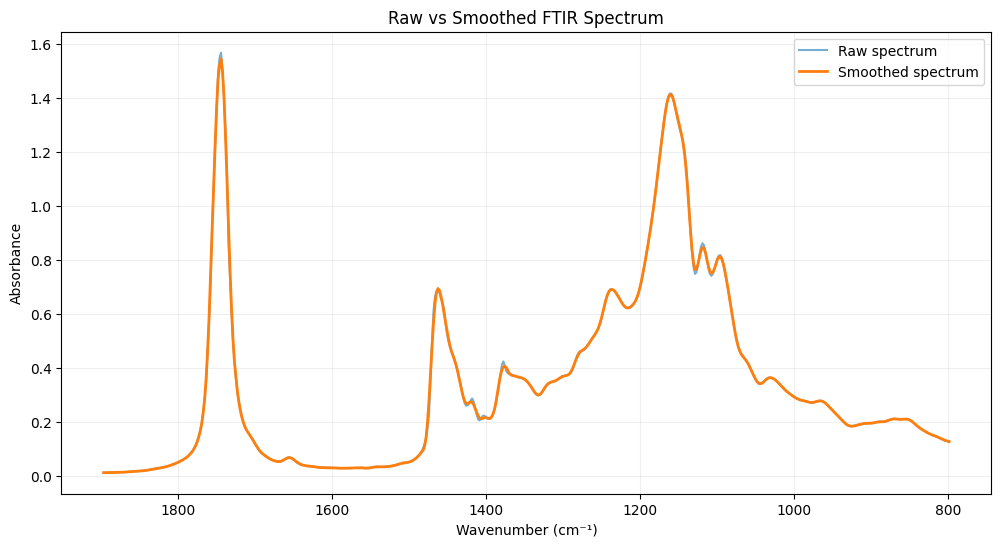

In [ ]:
sample = 0

plt.figure(figsize=(12, 6))

plt.plot(
    wavenumbers,
    X[sample],
    label="Raw spectrum",
    alpha=0.6
)

plt.plot(
    wavenumbers,
    X_smooth[sample],
    label="Smoothed spectrum",
    linewidth=2
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.title("Raw vs Smoothed FTIR Spectrum")

plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
from scipy import sparse
from scipy.sparse.linalg import spsolve

def baseline_correction(y, lam=100000, p=0.01, niter=10):
    """
    Asymmetric Least Squares baseline correction
    """
    L = len(y)

    D = sparse.diags(
        [1, -2, 1],
        [0, 1, 2],
        shape=(L - 2, L),
        format="csc"
    )

    w = np.ones(L)

    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)

        Z = W + lam * D.T @ D

        z = spsolve(Z, w * y)

        w = p * (y > z) + (1 - p) * (y < z)

    return y - z

In [ ]:
X_baseline = np.array([
    baseline_correction(spectrum)
    for spectrum in X_smooth
])

print("X_baseline:", X_baseline.shape)

X_baseline: (120, 570)


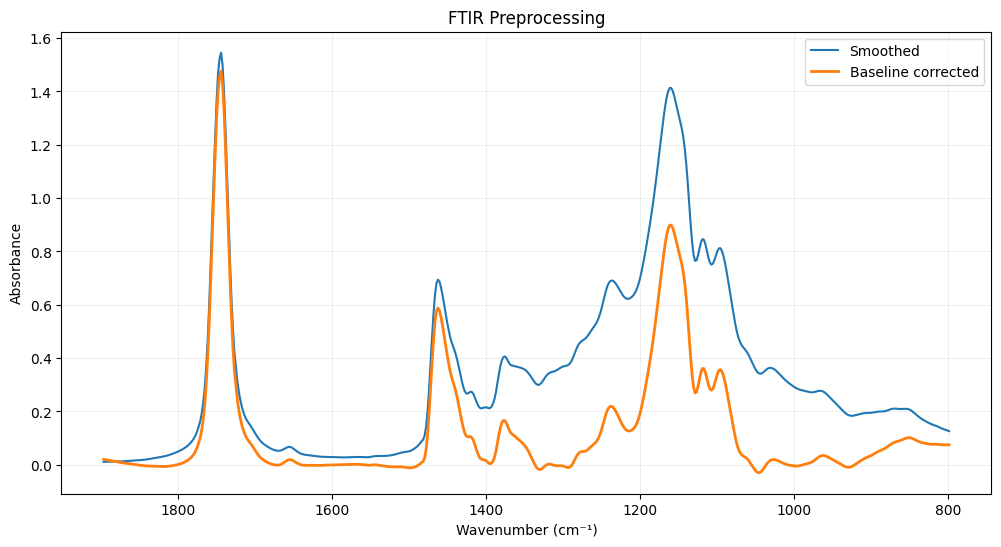

In [ ]:
sample = 0

plt.figure(figsize=(12, 6))

plt.plot(
    wavenumbers,
    X_smooth[sample],
    label="Smoothed"
)

plt.plot(
    wavenumbers,
    X_baseline[sample],
    label="Baseline corrected",
    linewidth=2
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.title("FTIR Preprocessing")

plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
def snv(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    return (X - mean) / std

In [ ]:
X_snv = snv(X_baseline)

print("X_snv:", X_snv.shape)

X_snv: (120, 570)


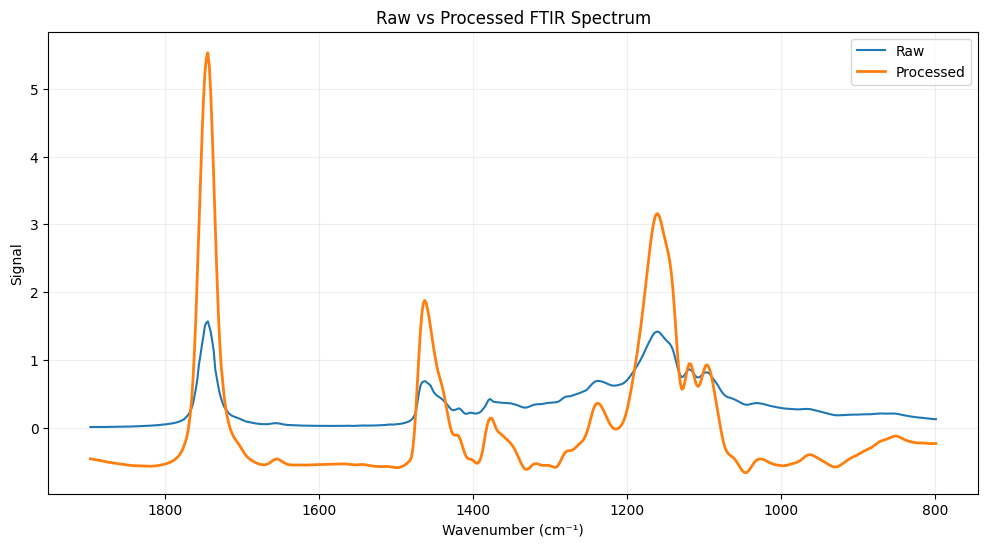

In [ ]:
sample = 0

plt.figure(figsize=(12, 6))

plt.plot(
    wavenumbers,
    X[sample],
    label="Raw"
)

plt.plot(
    wavenumbers,
    X_snv[sample],
    label="Processed",
    linewidth=2
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal")
plt.title("Raw vs Processed FTIR Spectrum")

plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
print("عدد Wavenumbers:", len(wavenumbers))
print("عدد نقاط الطيف:", X.shape[1])

print("أول Wavenumber:", wavenumbers[0])
print("آخر Wavenumber:", wavenumbers[-1])

عدد Wavenumbers: 570
عدد نقاط الطيف: 570
أول Wavenumber: 798.892
آخر Wavenumber: 1896.8085


In [ ]:
X_baseline = np.array([
    baseline_correction(spectrum)
    for spectrum in X_smooth
])

print("قبل المعالجة:", X_smooth.shape)
print("بعد Baseline Correction:", X_baseline.shape)

قبل المعالجة: (120, 570)
بعد Baseline Correction: (120, 570)


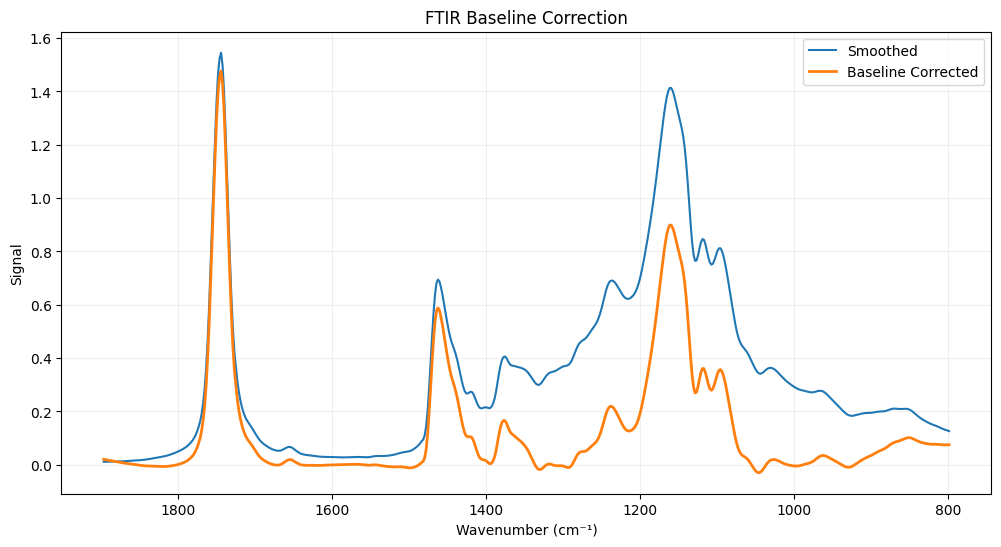

In [ ]:
sample = 0

plt.figure(figsize=(12, 6))

plt.plot(
    wavenumbers,
    X_smooth[sample],
    label="Smoothed"
)

plt.plot(
    wavenumbers,
    X_baseline[sample],
    label="Baseline Corrected",
    linewidth=2
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal")
plt.title("FTIR Baseline Correction")

plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
def snv(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    return (X - mean) / std

In [ ]:
X_processed = snv(X_baseline)

print("Processed data:", X_processed.shape)

Processed data: (120, 570)


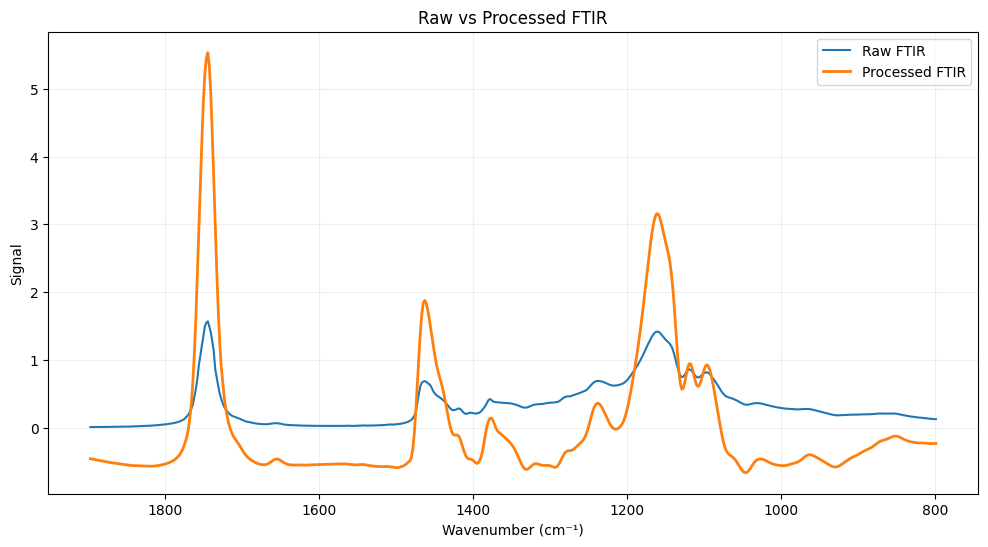

In [ ]:
sample = 0

plt.figure(figsize=(12, 6))

plt.plot(
    wavenumbers,
    X[sample],
    label="Raw FTIR"
)

plt.plot(
    wavenumbers,
    X_processed[sample],
    label="Processed FTIR",
    linewidth=2
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Signal")
plt.title("Raw vs Processed FTIR")

plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.2)

plt.show()

FTIR Dataset
     ↓
120 Samples × 570 Wavenumbers
     ↓
Savitzky-Golay
     ↓
Baseline Correction
     ↓
SNV Normalization
     ↓
X_processed

In [ ]:
print(metadata.head(20))

   Sample Group Country
0       1     1  Greece
1     1.1     1  Greece
2       2     1  Greece
3     2.1     1  Greece
4       3     1  Greece
5     3.1     1  Greece
6       4     1  Greece
7     4.1     1  Greece
8       5     1  Greece
9     5.1     1  Greece
10      6     1  Greece
11    6.1     1  Greece
12      7     1  Greece
13    7.1     1  Greece
14      8     1  Greece
15    8.1     1  Greece
16      9     1  Greece
17    9.1     1  Greece
18     10     1  Greece
19   10.1     1  Greece


In [ ]:
print(metadata["Sample"].head(20).tolist())

['1', '1.1', '2', '2.1', '3', '3.1', '4', '4.1', '5', '5.1', '6', '6.1', '7', '7.1', '8', '8.1', '9', '9.1', '10', '10.1']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale"
    ))
])

print("SVM model is ready!")

SVM model is ready!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    svm_model,
    X_processed,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.91666667 1.         1.         1.         1.        ]

Mean Accuracy:
0.9833333333333332

Standard Deviation:
0.03333333333333335


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    svm_model,
    X_processed,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.91666667 1.         1.         1.         1.        ]

Mean Accuracy:
0.9833333333333332

Standard Deviation:
0.03333333333333335


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_scores = cross_val_score(
    rf_model,
    X_processed,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Random Forest scores:")
print(rf_scores)

print("\nMean Accuracy:")
print(rf_scores.mean())

print("\nStandard Deviation:")
print(rf_scores.std())

Random Forest scores:
[0.91666667 1.         0.95833333 0.95833333 0.95833333]

Mean Accuracy:
0.9583333333333334

Standard Deviation:
0.026352313834736508


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000))
])

lr_scores = cross_val_score(
    lr_model,
    X_processed,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Logistic Regression scores:")
print(lr_scores)

print("\nMean Accuracy:")
print(lr_scores.mean())

print("\nStandard Deviation:")
print(lr_scores.std())

Logistic Regression scores:
[1. 1. 1. 1. 1.]

Mean Accuracy:
1.0

Standard Deviation:
0.0


In [ ]:
results = pd.DataFrame({
    "Model": [
        "SVM",
        "Random Forest",
        "Logistic Regression"
    ],
    "Mean Accuracy": [
        cv_scores.mean(),
        rf_scores.mean(),
        lr_scores.mean()
    ],
    "Std": [
        cv_scores.std(),
        rf_scores.std(),
        lr_scores.std()
    ]
})

results.sort_values(
    "Mean Accuracy",
    ascending=False
)

,Model,Mean Accuracy,Std
2,Logistic Regression,1.000000,0.000000
0,SVM,0.983333,0.033333
1,Random Forest,0.958333,0.026352


In [ ]:
print(metadata.head(20))

   Sample Group Country
0       1     1  Greece
1     1.1     1  Greece
2       2     1  Greece
3     2.1     1  Greece
4       3     1  Greece
5     3.1     1  Greece
6       4     1  Greece
7     4.1     1  Greece
8       5     1  Greece
9     5.1     1  Greece
10      6     1  Greece
11    6.1     1  Greece
12      7     1  Greece
13    7.1     1  Greece
14      8     1  Greece
15    8.1     1  Greece
16      9     1  Greece
17    9.1     1  Greece
18     10     1  Greece
19   10.1     1  Greece


In [ ]:
print(metadata["Sample"].head(20).tolist())

['1', '1.1', '2', '2.1', '3', '3.1', '4', '4.1', '5', '5.1', '6', '6.1', '7', '7.1', '8', '8.1', '9', '9.1', '10', '10.1']


🚀 Initializing FTIR Olive Oil Adulteration Detection AI Pipeline...

✅ Dataset successfully located at: /content/FTIR_Spectra_olive_oils.csv
📊 Transposed Dataset Shape: 120 Samples x 573 Features/Attributes


/tmp/ipykernel_1240/2897785143.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


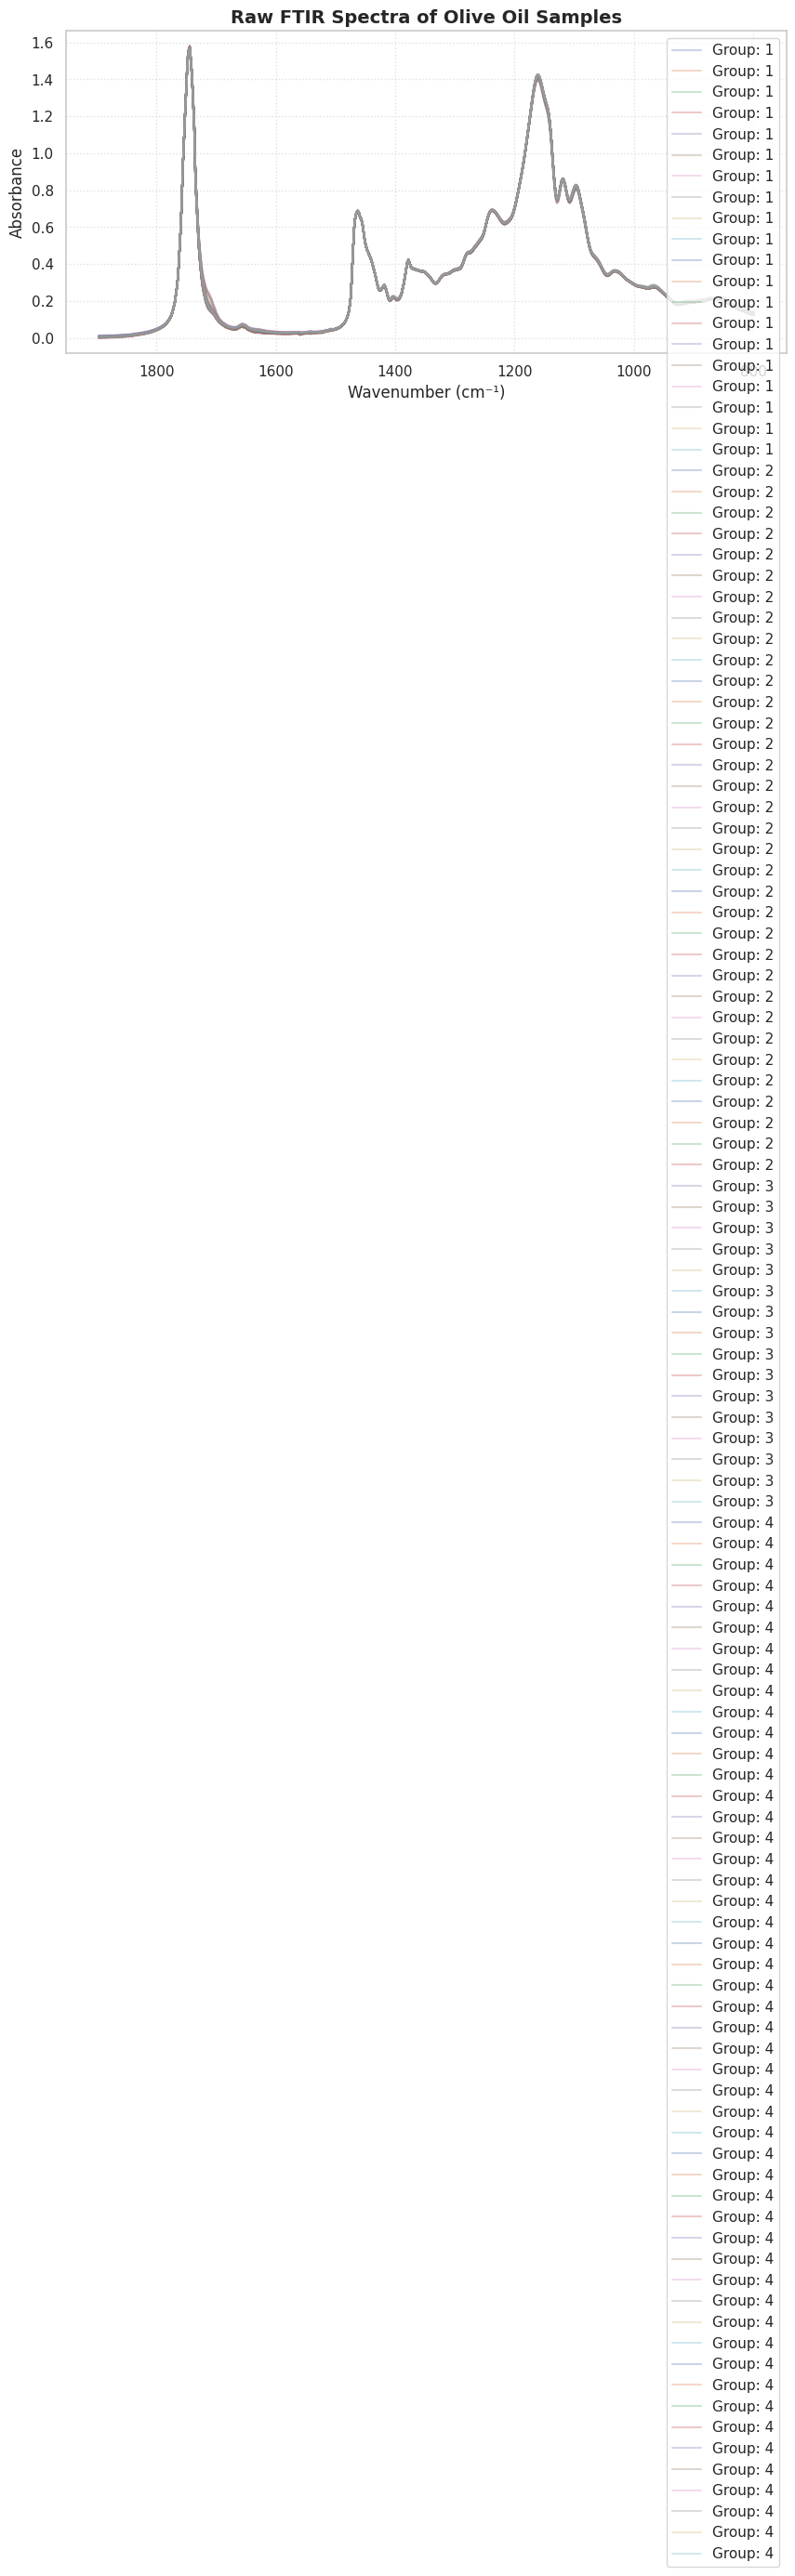

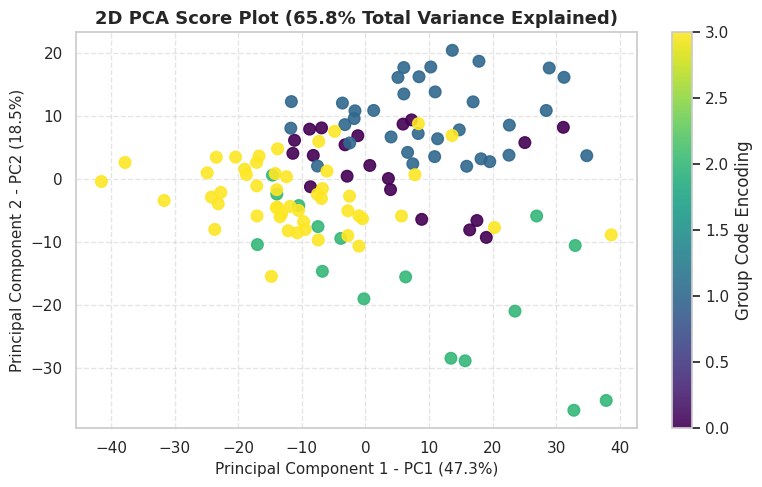


🤖 Comparing Classification Models using 5-Fold Stratified Cross-Validation
🔹 SVM (RBF Kernel)     | Mean Accuracy: 93.33% | Std Dev: ±3.33%
🔹 Random Forest        | Mean Accuracy: 90.83% | Std Dev: ±3.12%
🔹 Logistic Regression  | Mean Accuracy: 96.67% | Std Dev: ±3.12%

📊 [Detailed Classification Report - Selected Best Model]:
              precision    recall  f1-score   support

           1       0.80      1.00      0.89         4
           2       1.00      0.86      0.92         7
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00        10

    accuracy                           0.96        24
   macro avg       0.95      0.96      0.95        24
weighted avg       0.97      0.96      0.96        24



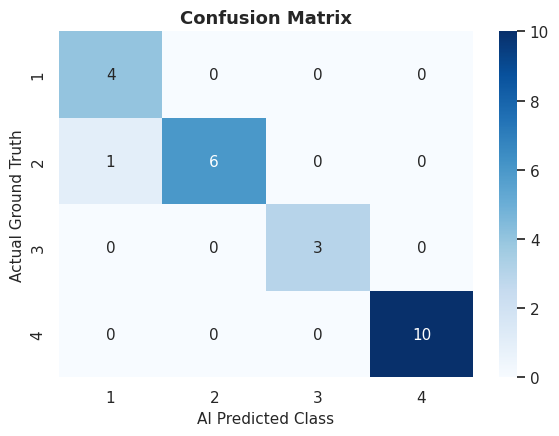

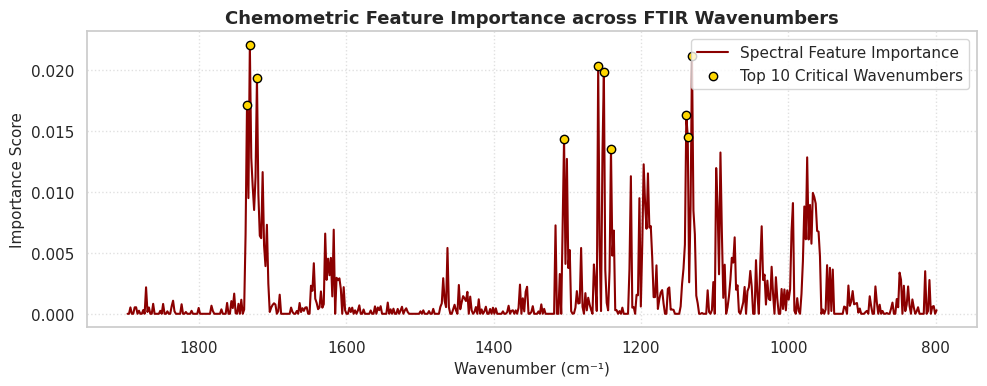

🔝 Top 5 Critical Wavenumbers Identified by the Model:
   • Wavenumber: 1730.9 cm⁻¹ (Contribution: 2.21%)
   • Wavenumber: 1130.8 cm⁻¹ (Contribution: 2.12%)
   • Wavenumber: 1258.1 cm⁻¹ (Contribution: 2.04%)
   • Wavenumber: 1250.4 cm⁻¹ (Contribution: 1.98%)
   • Wavenumber: 1721.2 cm⁻¹ (Contribution: 1.94%)

📈 Quantitative Adulteration Estimation via PLS Regression
✅ R² Score (Coefficient of Determination): 0.7924
✅ Root Mean Squared Error (RMSE): 0.5257

🧪 Interactive Olive Oil Rapid Screening Tool


In [43]:
# ==============================================================================
# Project: Rapid Detection of Olive Oil Adulteration using FTIR Spectra & AI
# Ultimate End-to-End Pipeline - Ready for Execution in Google Colab
# ==============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Evaluation Libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

# Interactive UI Libraries
import ipywidgets as widgets
from IPython.display import display, clear_output

# Set visual aesthetic for plots
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

print("🚀 Initializing FTIR Olive Oil Adulteration Detection AI Pipeline...\n")

# ==============================================================================
# 1. Data Ingestion & Automated Transpose
# ==============================================================================
possible_paths = [
    '/content/FTIR_Spectra_olive_oils.csv',
    '/content/drive/MyDrive/FTIR_Spectra_olive_oils.csv',
    'FTIR_Spectra_olive_oils.csv'
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if not data_path:
    print("❌ Error: 'FTIR_Spectra_olive_oils.csv' was not found. Please upload the dataset first.")
else:
    print(f"✅ Dataset successfully located at: {data_path}")

    # Load raw dataset
    df_raw = pd.read_csv(data_path, header=None)

    # Transpose dataset (Samples as rows, Wavenumbers as columns)
    df = df_raw.T
    df.columns = df.iloc[0]
    df = df.drop(0).reset_index(drop=True)

    # Sanitize column headers
    df.columns = df.columns.astype(str).str.strip().str.replace(':', '')

    print(f"📊 Transposed Dataset Shape: {df.shape[0]} Samples x {df.shape[1]} Features/Attributes")

    # Identify label and wavenumber columns
    label_col = 'Group Code' if 'Group Code' in df.columns else df.columns[1]
    wavenumber_cols = df.columns[3:]
    wavenumbers = wavenumber_cols.astype(float)

    X = df[wavenumber_cols].values.astype(float)
    y = df[label_col].values

    # ==============================================================================
    # 2. Raw FTIR Spectra Visualization
    # ==============================================================================
    plt.figure(figsize=(10, 4.5))
    unique_groups = np.unique(y)
    for group in unique_groups:
        mask = (y == group)
        plt.plot(wavenumbers, X[mask].T, alpha=0.3, label=f'Group: {group}')

    plt.gca().invert_xaxis()  # Invert x-axis according to FTIR spectroscopy standard convention
    plt.title('Raw FTIR Spectra of Olive Oil Samples', fontsize=14, fontweight='bold')
    plt.xlabel('Wavenumber (cm⁻¹)', fontsize=12)
    plt.ylabel('Absorbance', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # 3. Principal Component Analysis (PCA)
    # ==============================================================================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    var_exp = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.Categorical(y).codes, cmap='viridis', s=70, alpha=0.9)
    plt.title(f'2D PCA Score Plot ({var_exp.sum():.1f}% Total Variance Explained)', fontsize=13, fontweight='bold')
    plt.xlabel(f'Principal Component 1 - PC1 ({var_exp[0]:.1f}%)', fontsize=11)
    plt.ylabel(f'Principal Component 2 - PC2 ({var_exp[1]:.1f}%)', fontsize=11)
    plt.colorbar(scatter, label='Group Code Encoding')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # 4. Machine Learning Model Comparison & Evaluation
    # ==============================================================================
    print("\n" + "="*65)
    print("🤖 Comparing Classification Models using 5-Fold Stratified Cross-Validation")
    print("="*65)

    models = {
        'SVM (RBF Kernel)': Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', C=10, gamma='scale'))]),
        'Random Forest': Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=100, random_state=42))]),
        'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=42))])
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, pipeline in models.items():
        scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
        print(f"🔹 {name:20s} | Mean Accuracy: {scores.mean()*100:.2f}% | Std Dev: ±{scores.std()*100:.2f}%")

    # Train/Test Split for Final Model Evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    best_pipeline = models['Random Forest']
    best_pipeline.fit(X_train, y_train)
    y_pred = best_pipeline.predict(X_test)

    print("\n📊 [Detailed Classification Report - Selected Best Model]:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)
    plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('AI Predicted Class', fontsize=11)
    plt.ylabel('Actual Ground Truth', fontsize=11)
    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # 5. Chemometric Feature Importance (Wavenumbers)
    # ==============================================================================
    rf_model = best_pipeline.named_steps['rf']
    importances = rf_model.feature_importances_

    top_indices = np.argsort(importances)[::-1][:10]

    plt.figure(figsize=(10, 4))
    plt.plot(wavenumbers, importances, color='darkred', lw=1.5, label='Spectral Feature Importance')
    plt.scatter(wavenumbers[top_indices], importances[top_indices], color='gold', edgecolor='black', zorder=5, label='Top 10 Critical Wavenumbers')
    plt.gca().invert_xaxis()
    plt.title('Chemometric Feature Importance across FTIR Wavenumbers', fontsize=13, fontweight='bold')
    plt.xlabel('Wavenumber (cm⁻¹)', fontsize=11)
    plt.ylabel('Importance Score', fontsize=11)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("🔝 Top 5 Critical Wavenumbers Identified by the Model:")
    for idx in top_indices[:5]:
        print(f"   • Wavenumber: {wavenumbers[idx]:.1f} cm⁻¹ (Contribution: {importances[idx]*100:.2f}%)")

    # ==============================================================================
    # 6. Quantitative Estimation via Partial Least Squares (PLS) Regression
    # ==============================================================================
    print("\n" + "="*65)
    print("📈 Quantitative Adulteration Estimation via PLS Regression")
    print("="*65)

    try:
        y_numeric = pd.to_numeric(y, errors='coerce')
        if not np.isnan(y_numeric).any():
            X_tr_s = scaler.fit_transform(X_train)
            X_te_s = scaler.transform(X_test)

            pls = PLSRegression(n_components=3)
            pls.fit(X_tr_s, y_train.astype(float))
            y_pls_pred = pls.predict(X_te_s)

            r2 = r2_score(y_test.astype(float), y_pls_pred)
            rmse = np.sqrt(mean_squared_error(y_test.astype(float), y_pls_pred))

            print(f"✅ R² Score (Coefficient of Determination): {r2:.4f}")
            print(f"✅ Root Mean Squared Error (RMSE): {rmse:.4f}")
    except Exception as e:
        print("💡 Quantitative regression step bypassed based on label format.")

    # ==============================================================================
    # 7. Interactive Rapid Screening Tool (Google Colab UI Widget)
    # ==============================================================================
    print("\n" + "="*65)
    print("🧪 Interactive Olive Oil Rapid Screening Tool")
    print("="*65)

    X_test_scaled = best_pipeline.named_steps['scaler'].transform(X_test)

    dropdown = widgets.Dropdown(
        options=[(f"Sample #{i+1} (Actual Class: {y_test[i]})", i) for i in range(len(X_test))],
        description='Select Sample:',
        layout=widgets.Layout(width='360px')
    )

    button = widgets.Button(
        description="🔍 Analyze Spectrum with AI",
        button_style='success',
        layout=widgets.Layout(width='240px')
    )

    out = widgets.Output()

    def on_click_analyze(b):
        with out:
            clear_output()
            idx = dropdown.value
            sample_feats = X_test_scaled[idx].reshape(1, -1)
            actual = y_test[idx]

            pred = rf_model.predict(sample_feats)[0]
            probs = rf_model.predict_proba(sample_feats)[0]
            confidence = np.max(probs) * 100

            print("-" * 55)
            print(f"🤖 AI Predicted Category : {pred}")
            print(f"🎯 Actual Ground Truth  : {actual}")
            print(f"🎯 Prediction Confidence : {confidence:.2f}%")
            print("-" * 55)

            if str(pred) == str(actual):
                print("✨ Verification Result: Perfect Match (Correct Classification).")
            else:
                print("⚠️ Verification Result: Misclassified Sample.")

            plt.figure(figsize=(8, 3))
            plt.plot(wavenumbers, X_test[idx], color='teal', lw=1.5, label=f'Sample #{idx+1}')
            plt.gca().invert_xaxis()
            plt.title(f'Analyzed FTIR Spectrum (AI Prediction: {pred})', fontsize=11)
            plt.xlabel('Wavenumber (cm⁻¹)')
            plt.ylabel('Absorbance')
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.legend()
            plt.tight_layout()
            plt.show()

    button.on_click(on_click_analyze)
    display(widgets.VBox([dropdown, button, out]))

